In [1]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io
# this DataFrame contains all of the event meta data
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])

# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

# import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 去重，确保每个事件只保留一行
events = df.drop_duplicates(subset=['id']).copy()

# 时间划分
events['start_date'] = pd.to_datetime(events['start_utc']).dt.date
events['month'] = pd.to_datetime(events['start_utc']).dt.month
events['season'] = events['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# 地理区域划分
def assign_region(row):
    if row['llcrnrlat'] > 40:  # 纬度划分
        return 'North'
    elif row['llcrnrlat'] < 30:
        return 'South'
    elif row['llcrnrlon'] < -100:  # 经度划分
        return 'West'
    else:
        return 'East'

events['region'] = events.apply(assign_region, axis=1)

# 分层抽样划分
train_events, val_events = train_test_split(
    events,
    test_size=0.3,  # 验证集比例
    stratify=events[['season', 'region']],  # 按季节和区域分层
    random_state=42
)

val_events, test_events = train_test_split(
    val_events,
    test_size=0.5,  # 测试集比例
    stratify=val_events[['season', 'region']],  # 按季节和区域分层
    random_state=42
)

train_ids = train_events['id']
val_ids = val_events['id']
test_ids = test_events['id']
print(f"训练集大小: {len(train_ids)}")
print(f"验证集大小: {len(val_ids)}")
print(f"测试集大小: {len(test_ids)}")
#train_ids = train_ids[:56]
#val_ids = val_ids[:12]
#test_ids = test_ids[:12]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


训练集大小: 560
验证集大小: 120
测试集大小: 120


In [2]:

import torch
import torch.nn.functional as F
import numpy as np

def process_data(event_ids):

    # 预定义数据大小（假设 N 是已知的）
    N = len(event_ids)
    H, W = 384, 384
    input_channels = 3  # 3 通道的时间序列长度 36
    target_channels = 1  # vil 时间序列 36
    frames = 36
    # 直接分配 tensor 避免 list append
    data_inputs = torch.empty((N, frames, input_channels, H, W), dtype=torch.float32)
    data_targets = torch.empty((N, frames, target_channels, H, W), dtype=torch.float32)

    for i, id in enumerate(event_ids):
        event = load_event(id)

        # 读取数据并转换为 Tensor
        vis = torch.from_numpy(event['vis'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0)  # (36, 384, 384)
        ir069 = torch.from_numpy(event['ir069'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0)  # (36, 原始 H, W)
        ir107 = torch.from_numpy(event['ir107'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0)  # (36, 原始 H, W)
        vil = torch.from_numpy(event['vil'].astype(np.float32)).permute(2, 0, 1).unsqueeze(1)  # (36, 384, 384)

        # 上采样红外数据到 384x384
        ir069 = F.interpolate(ir069, size=(H, W), mode='bilinear', align_corners=False)
        ir107 = F.interpolate(ir107, size=(H, W), mode='bilinear', align_corners=False)

        # 归一化

        def normalize(tensor):
            min_val = tensor.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]  # 只计算一次 min
            max_val = tensor.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0]  # 只计算一次 max
            return (tensor - min_val) / (max_val - min_val + 1e-8)  # 避免除零错误

        vis = normalize(vis)
        ir069 = normalize(ir069)
        ir107 = normalize(ir107)
        vil = normalize(vil)

        # 合并输入通道 (3, 36, 384, 384)
        inputs = torch.cat([vis, ir069, ir107], dim=0).permute(1, 0, 2, 3)  # (36, 3, 384, 384)

        # 存入预分配张量
        data_inputs[i] = inputs
        data_targets[i] = vil

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{N}")
    data_inputs = data_inputs.view(N * frames, 3, 384, 384)
    data_targets = data_targets.view(N * frames, 1, 384, 384)
    return data_inputs, data_targets
train_inputs, train_targets = process_data(train_ids)
val_inputs, val_targets = process_data(val_ids)
test_inputs, test_targets = process_data(test_ids)
# 检查最终形状
print("Final Input Shape:", train_inputs.shape, "Final Target Shape:", train_targets.shape)
print("Final Input Shape:", val_inputs.shape, "Final Target Shape:", val_targets.shape)
print("Final Input Shape:", test_inputs.shape, "Final Target Shape:", test_targets.shape)

Processed 10/560
Processed 20/560
Processed 30/560
Processed 40/560
Processed 50/560
Processed 60/560
Processed 70/560
Processed 80/560
Processed 90/560
Processed 100/560
Processed 110/560
Processed 120/560
Processed 130/560
Processed 140/560
Processed 150/560
Processed 160/560
Processed 170/560
Processed 180/560
Processed 190/560
Processed 200/560
Processed 210/560
Processed 220/560
Processed 230/560
Processed 240/560
Processed 250/560
Processed 260/560
Processed 270/560
Processed 280/560
Processed 290/560
Processed 300/560
Processed 310/560
Processed 320/560
Processed 330/560
Processed 340/560
Processed 350/560
Processed 360/560
Processed 370/560
Processed 380/560
Processed 390/560
Processed 400/560
Processed 410/560
Processed 420/560
Processed 430/560
Processed 440/560
Processed 450/560
Processed 460/560
Processed 470/560
Processed 480/560
Processed 490/560
Processed 500/560
Processed 510/560
Processed 520/560
Processed 530/560
Processed 540/560
Processed 550/560
Processed 560/560
P

In [18]:
"""
import h5py
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import RandomHorizontalFlip, RandomVerticalFlip, RandomRotation
import torch.nn.functional as F

# 自定义数据集类
class StormDataset(Dataset):
    def __init__(self, h5_path, event_ids):
        self.h5_path = h5_path
        self.event_ids = event_ids

        # 初始化HDF5文件句柄（多进程安全）
        self.file = h5py.File(h5_path, 'r')
        self.channel_ranges = {
            'vis': (-136, 12529),    # 示例值，需替换为实际统计
            'ir069': (-8378, -992),
            'ir107': (-8426, 4363)
        }
    def __len__(self):
        return len(self.event_ids)*36

    def __getitem__(self, idx):

        event_id = self.event_ids[idx//36]
        group = self.file[event_id]
        frame_idx = idx % 36
        vis = group['vis'][:,:,frame_idx].astype(np.float32)     # (H, W, T)
        ir069 = group['ir069'][:,:,frame_idx].astype(np.float32)
        ir107 = group['ir107'][:,:,frame_idx].astype(np.float32)
        vil = group['vil'][:,:,frame_idx].astype(np.float32)
        # 转换为float32并归一化
        def scale_channel(data, channel):
            min_val, max_val = self.channel_ranges[channel]
            data = np.clip(data, min_val, max_val)  # 处理异常值
            return (data - min_val) / (max_val - min_val)  # 缩放到[0,1]
        """
        vis = scale_channel(vis, 'vis').astype(np.float32)
        ir069 = scale_channel(ir069, 'ir069').astype(np.float32)
        ir107 = scale_channel(ir107, 'ir107').astype(np.float32)
        """
        # 转换为PyTorch格式 (C, H, W, T)
        vis = torch.from_numpy(vis).unsqueeze(0).unsqueeze(0)    # (1, 1, 384, 384)
        ir069 = torch.from_numpy(ir069).unsqueeze(0).unsqueeze(0)
        ir107 = torch.from_numpy(ir107).unsqueeze(0).unsqueeze(0)
        vil = torch.from_numpy(vil).unsqueeze(0).unsqueeze(0)    # (1, 1, 384, 384)

        # 上采样红外数据到384x384
        ir069 = F.interpolate(ir069, size=(384,384), mode='bilinear', align_corners=False)
        ir107 = F.interpolate(ir107, size=(384,384), mode='bilinear', align_corners=False)

        # 合并输入通道 (3, T, H, W)
        inputs = torch.cat([vis, ir069, ir107], dim=1).squeeze(0)  # (3, 384, 384)

        targets = vil.float() / 255.0  # 归一化到[0,1]
        targets = targets.squeeze(0)  # (1, 384, 384)

        return {'inputs':inputs, 'target':targets}
"""

In [3]:
import h5py
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import RandomHorizontalFlip, RandomVerticalFlip, RandomRotation
import torch.nn.functional as F

# 自定义数据集类
class StormDataset(Dataset):
    def __init__(self, data_inputs, data_targets):
        self.data_inputs = data_inputs
        self.data_targets = data_targets
    def __len__(self):
        return self.data_inputs.shape[0]

    def __getitem__(self, idx):
        inputs = self.data_inputs[idx]
        target = self.data_targets[idx]

        return inputs, target

In [8]:
# 创建DataLoader
batch_size = 36
train_dataset = StormDataset(train_inputs, train_targets)
train_loader = DataLoader(train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)
val_dataset =StormDataset(val_inputs, val_targets)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
train_input, train_target = next(iter(train_loader))
print(f"✅ Data Loaded: Input {train_input.shape}, Target {train_target.shape}")
val_input, val_target = next(iter(val_loader))
print(f"✅ Data Loaded: Input {val_input.shape}, Target {val_target.shape}")

✅ Data Loaded: Input torch.Size([36, 3, 384, 384]), Target torch.Size([36, 1, 384, 384])
✅ Data Loaded: Input torch.Size([36, 3, 384, 384]), Target torch.Size([36, 1, 384, 384])


In [14]:
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # 编码器
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)

        # Bottleneck
        self.bottleneck = self.conv_block(256, 512)

        # 解码器
        self.up3 = self.up_conv(512, 256)
        self.dec3 = self.conv_block(512, 256)
        self.up2 = self.up_conv(256, 128)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = self.up_conv(128, 64)
        self.dec1 = self.conv_block(128, 64)

        # 最终输出
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def up_conv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(F.max_pool2d(enc1, 2))
        enc3 = self.enc3(F.max_pool2d(enc2, 2))

        bottleneck = self.bottleneck(F.max_pool2d(enc3, 2))

        up3 = self.up3(bottleneck)
        dec3 = self.dec3(torch.cat([up3, enc3], dim=1))
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc2], dim=1))
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, enc1], dim=1))

        return self.final(dec1)


def evaluate(model, criterion, val_loader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            inputs = batch[0].to(device, non_blocking=True, memory_format=torch.channels_last)
            targets = batch[1].to(device, non_blocking=True, memory_format=torch.channels_last)

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)

    return total_loss / len(val_loader.dataset)

import torch
import torch.backends.cudnn as cudnn
from torch.cuda.amp import autocast, GradScaler

from tqdm import tqdm

# 启用 cuDNN 加速
cudnn.benchmark = True
cudnn.enabled = True

# 混合精度训练
scaler = GradScaler()

def evaluate(model, criterion, val_loader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            inputs = batch[0].to(device, non_blocking=True, memory_format=torch.channels_last)
            targets = batch[1].to(device, non_blocking=True, memory_format=torch.channels_last)

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)

    return total_loss / len(val_loader.dataset)

def train(model, criterion, optimizer, train_loader, val_loader, device, epochs=100, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        with tqdm(train_loader, unit="batch", desc=f"Epoch {epoch+1}/{epochs}") as pbar:
            for batch in pbar:
                inputs = batch[0].to(device, non_blocking=True, memory_format=torch.channels_last)
                targets = batch[1].to(device, non_blocking=True, memory_format=torch.channels_last)

                optimizer.zero_grad()

                with autocast():  # 混合精度
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        val_loss = evaluate(model, criterion, val_loader, device)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 逻辑
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Early stopping counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered. Stopping training.")
                break

    return train_losses, val_losses

# 训练示例
device = "cuda"
criterion = nn.MSELoss()
model = UNet().to(device, memory_format=torch.channels_last)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
train_loss, val_losses = train(model, criterion, optimizer, train_loader, val_loader, device, epochs=50, patience=5)


<ipython-input-14-ed3723296b24>:85: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/50:   0%|          | 0/560 [00:00<?, ?batch/s]<ipython-input-14-ed3723296b24>:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # 混合精度
Validating:   0%|          | 0/120 [00:00<?, ?it/s]<ipython-input-14-ed3723296b24>:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50 - Train Loss: 0.0512 | Val Loss: 0.0495


Epoch 2/50: 100%|██████████| 560/560 [01:30<00:00,  6.20batch/s]


Epoch 2/50 - Train Loss: 0.0445 | Val Loss: 0.0458


Epoch 3/50: 100%|██████████| 560/560 [01:30<00:00,  6.19batch/s]


...

Epoch 11/50 - Train Loss: 0.0358 | Val Loss: 0.0436
Early stopping counter: 3/5


Epoch 12/50: 100%|██████████| 560/560 [01:30<00:00,  6.20batch/s]


Epoch 12/50 - Train Loss: 0.0353 | Val Loss: 0.0442
Early stopping counter: 4/5


Epoch 13/50: 100%|██████████| 560/560 [01:30<00:00,  6.19batch/s]
                                                             

Epoch 13/50 - Train Loss: 0.0346 | Val Loss: 0.0439
Early stopping counter: 5/5
Early stopping triggered. Stopping training.


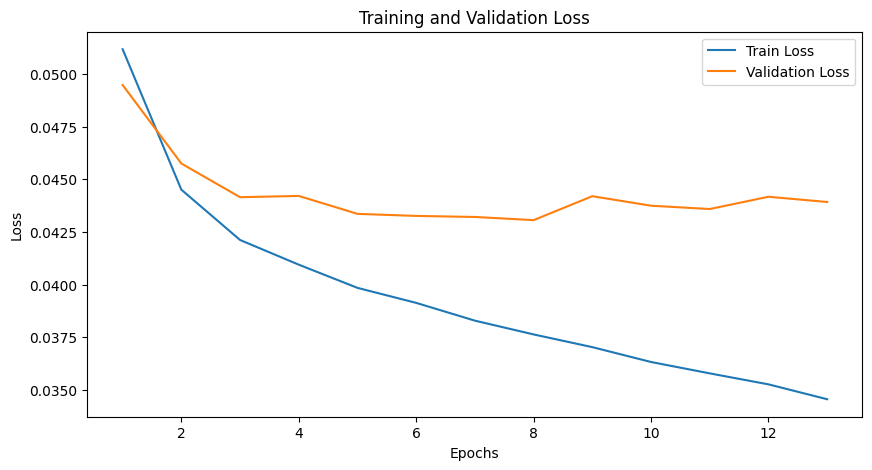

In [16]:
    import matplotlib.pyplot as plt
    epochs = len(train_loss)
    # 画 loss 曲线
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), train_loss, label='Train Loss')
    plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

In [ ]:

"""
model = UNet().cuda()
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 2
#from pytorch_msssim import ssim
for epoch in range(epochs):
    model.train()
    train_losses = []
    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} (Training)", unit="batch") as pbar:
        for batch in pbar:
          inputs = batch['inputs'].to("cuda")
          target = batch['target'].to("cuda")

          optimizer.zero_grad()
          output = model(inputs)
          loss = criterion(output, target)
          loss_L1 = nn.L1Loss()(output, target)
          #loss_ssim = 1 - ssim(output, target, data_range=1)
          loss = loss_L1
          loss.backward()
          optimizer.step()
          train_losses.append(loss.item())
          pbar.set_postfix({
              "Batch Loss": f"{loss.item():.4f}",
          })
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {np.mean(train_losses):.4f}")
"""

torch.Size([1, 3, 384, 384])
torch.Size([1, 1, 384, 384])
(1, 384, 384)


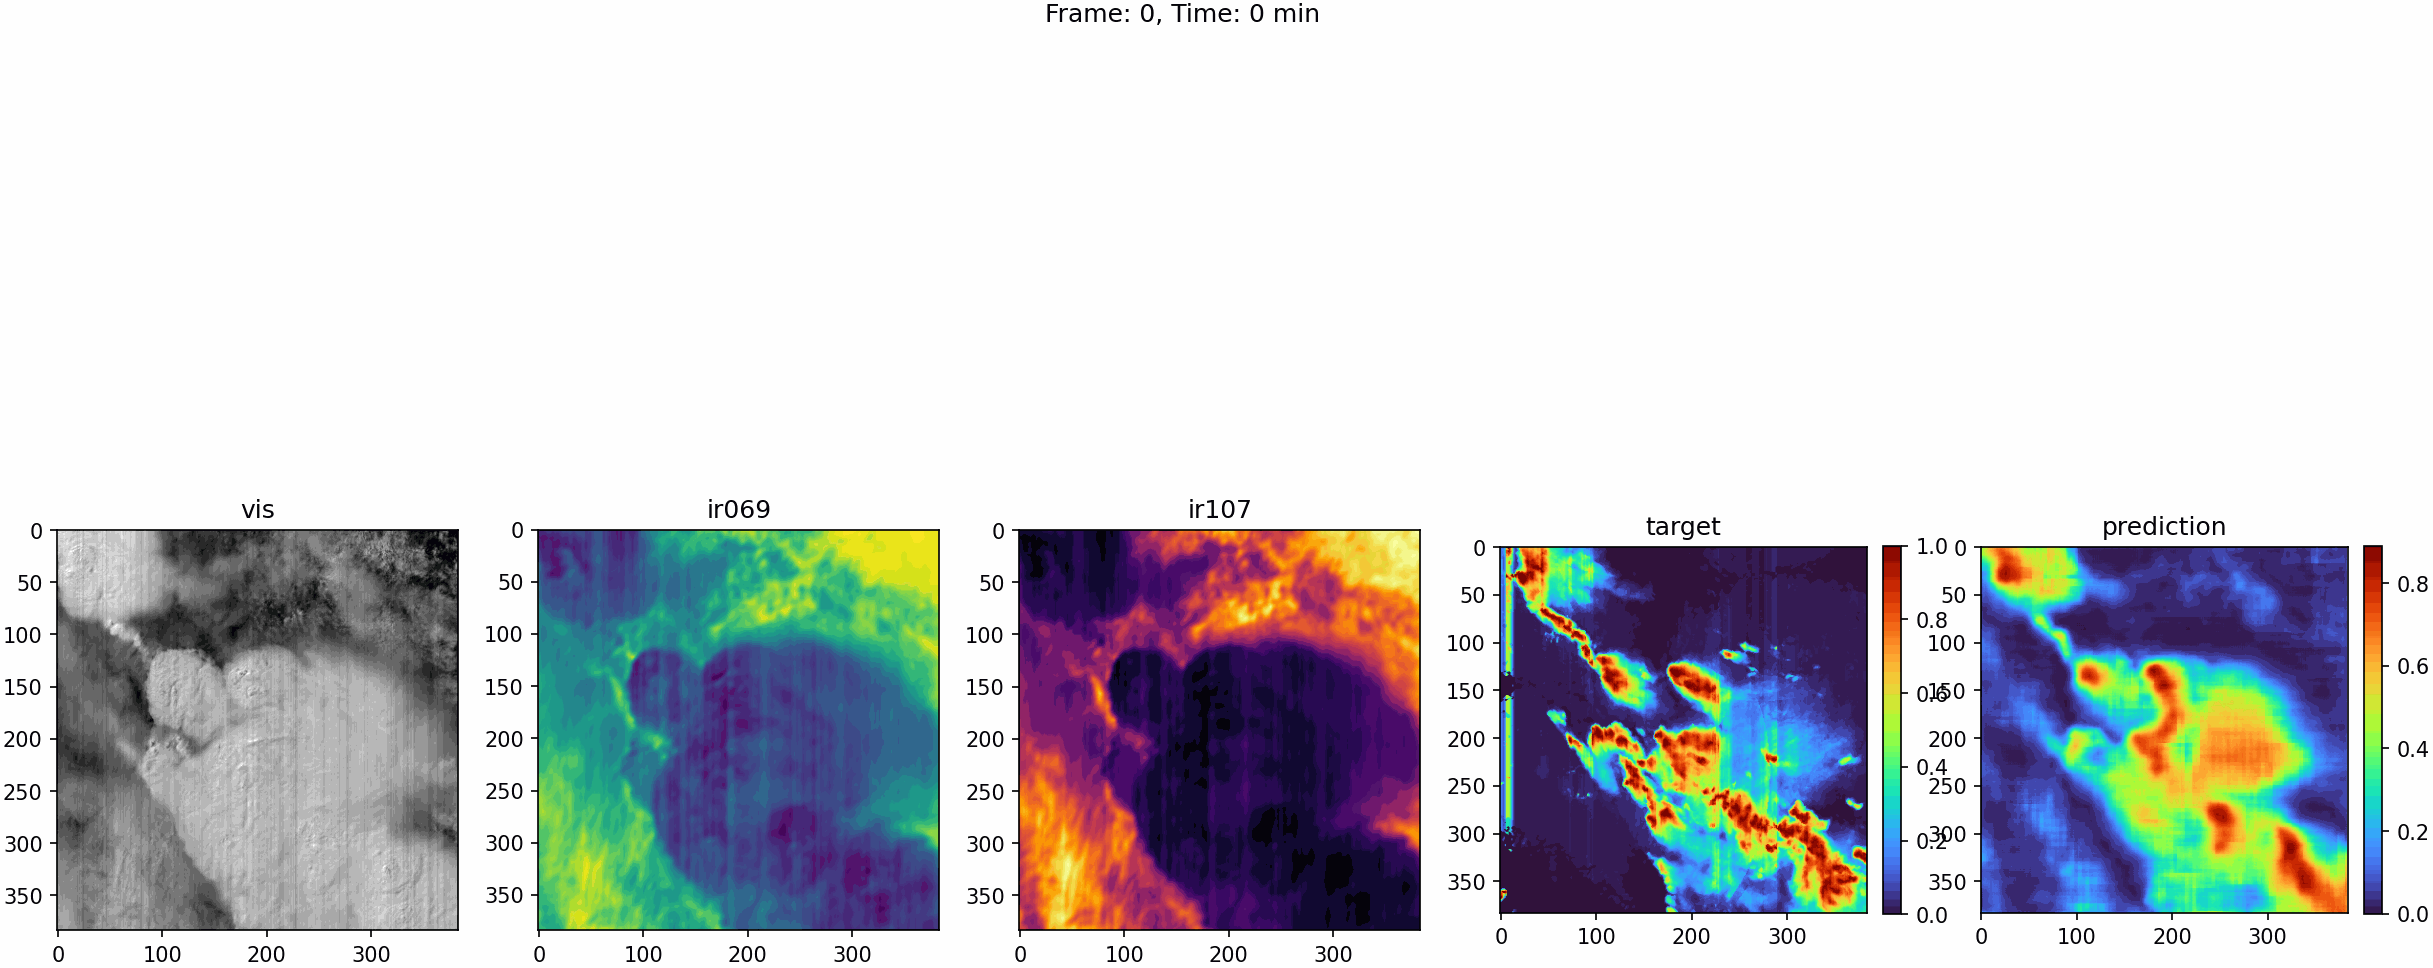

In [31]:
device="cuda"
model.to(device)
model.eval()

# 取一条数据 (一个 batch)
with torch.no_grad():
    for batch in val_loader:
        inputs = batch[0][0:1].to(device)   # (1, 3, 384, 384)
        target = batch[1][0:1].to(device)   # (1, 1, 384, 384)
        break  # 只取一个 batch
    print(inputs.shape)
    vis = inputs[0][0].cpu().numpy()
    ir069 = inputs[0][1].cpu().numpy()
    ir107 = inputs[0][2].cpu().numpy()
    prediction = model(inputs)
    print(prediction.shape)
    target = target.cpu().numpy()[0]
    print(target.shape)
    prediction = prediction.cpu().numpy()[0]
import matplotlib.pyplot as plt

def make_gif(outfile, files, fps=10, loop=0):
    "Helper function for saving GIFs"
    imgs = [PIL.Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='gif', append_images=imgs[1:],
                 save_all=True, duration=int(1000/fps), loop=loop)
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im

def plot_event(output_gif=False, save_gif=False, frames=36):

    def plot_frame(ti):

        fig,axs = plt.subplots(1,5,figsize=(20,10))
        fig.suptitle(f"Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(vis, cmap="grey"), axs[0].set_title('vis')
        axs[1].imshow(ir069, cmap="viridis"), axs[1].set_title('ir069')
        axs[2].imshow(ir107, cmap="inferno"), axs[2].set_title('ir107')
        im3 = axs[3].imshow(target[ti], cmap="turbo")
        axs[3].set_title('target')
        fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)  # 给 target 添加 colorbar

        im4 = axs[4].imshow(prediction[ti], cmap="turbo")
        axs[4].set_title('prediction')
        fig.colorbar(im4, ax=axs[4], fraction=0.046, pad=0.04)

        axs[4].set_xlim(0,384), axs[1].set_ylim(384,0)

        if output_gif:
            file = f"_temp_{id}_{ti}.png"
            fig.savefig(file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close()
        else:
            plt.show()
    if output_gif:
        for ti in range(frames): plot_frame(ti)
        im = make_gif(f"{id}.gif", [f"_temp_{id}_{ti}.png" for ti in range(frames)])
        for ti in range(frames): os.remove(f"_temp_{id}_{ti}.png")
        IPython.display.display(im)
        if not save_gif: os.remove(f"{id}.gif")
    else:
        plot_frame(0)
        plot_frame(17)
        plot_frame(34)

plot_event(output_gif=True, save_gif=True, frames=1)

In [20]:
torch.save(model.state_dict(), 'model_single_frame.pth')